In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import hashlib
import json
import os
from experiments.plots_style import apply_style
apply_style()
from experiments.plots import PlotGenerator

In [2]:
plotgen = PlotGenerator()
hashes = plotgen._generate_experiment_hash('experiments/experiment__micro_benchmarks/v3/config.csv')

In [4]:
df, config_df = plotgen._create_experiment_dfs('experiments/experiment__micro_benchmarks/v3/logs', hashes)

/home/fedor/Fast_Data_Discovery/experiments/plots.py:67: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  config_df = pl.DataFrame(hashes, schema=['var_threshold', 'corr_threshold', 'query_col_cardinality', 'config_hash'])


In [5]:
retrieval = plotgen._create_retrieval_df(df, config_df)

In [15]:
[np.log(x) for x in x]

[np.float64(1.6094379124341003),
 np.float64(5.442417710521793),
 np.float64(8.027802848370312),
 np.float64(8.860499167616016)]

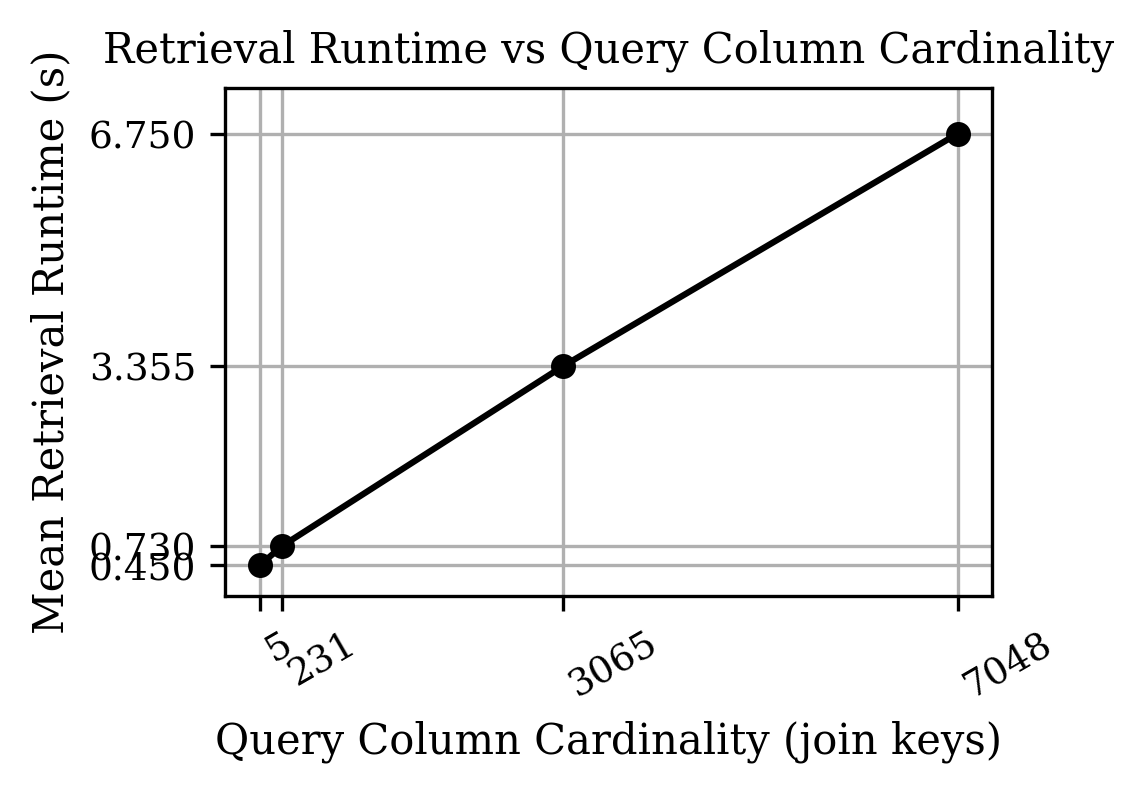

In [32]:
x = retrieval['query_col_cardinality'].to_list()
y = retrieval['runtime'].to_list()

plt.plot(x, y, marker='o')
plt.xlabel('Query Column Cardinality (join keys)')
plt.ylabel('Mean Retrieval Runtime (s)')
plt.title('Retrieval Runtime vs Query Column Cardinality')
plt.xticks(x, rotation=30, ha='left')
plt.yticks(y)
plt.ylim(0, max(y) * 1.1)
plt.grid(True)
plt.show()

In [27]:
pruning = plotgen._create_pruning_df(df, config_df)

In [31]:
pruning

query_col_cardinality,var_threshold,corr_threshold,runtime
i64,i32,f64,f64
5,0,0.0,5.6376e-7
231,0,0.0,6.6807e-7
231,0,0.55,2.468218
3065,0,0.55,6.423258
3065,0,0.0,6.1219e-7
7048,0,0.55,10.797586
7048,0,0.0,9.8472e-7


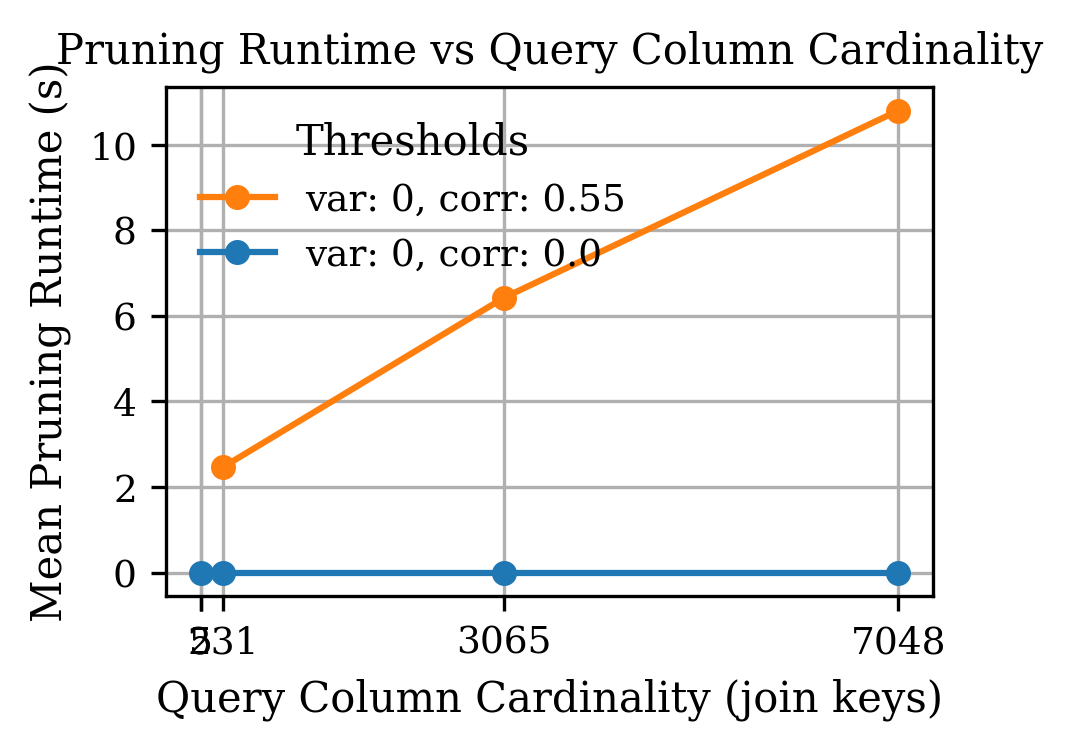

In [33]:
for (var_threshold, corr_threshold), group in pruning.group_by(['var_threshold', 'corr_threshold']):
    group = group.sort(['var_threshold', 'corr_threshold'])
    if var_threshold > 0 and corr_threshold == 0.0:
        np.random.seed(42)
        group = group.with_columns(pl.col('runtime') + 1+ np.random.rand())
    x_pruning = group['query_col_cardinality'].to_list()
    y_pruning = group['runtime'].to_list()
    colors = {
        (0.0, 0.0): 'tab:blue',
        (0.0, 0.55): 'tab:orange'
    }
    color = colors.get((var_threshold, corr_threshold), 'tab:gray')
    plt.plot(x_pruning, y_pruning, marker='o',
             label=f"var: {var_threshold}, corr: {corr_threshold}",
             color=color)

plt.xlabel('Query Column Cardinality (join keys)')
plt.ylabel('Mean Pruning Runtime (s)')
plt.title('Pruning Runtime vs Query Column Cardinality')
plt.legend(title="Thresholds")
plt.xticks([5]+x_pruning)
plt.grid(True)
plt.show()

In [ ]:
post_retrieval = (
    df
        .filter(
            (pl.col('message') != 'Retrieval')
                &
            (pl.col('message') != 'Pruning')
        )
        .select(['message', 'config', 'runtime'])
        .join(config_df, left_on='config', right_on='config_hash', how='left')
        .with_columns(pl.col(['var_threshold', 'corr_threshold']).fill_null(0))
)
post_retrieval = post_retrieval.group_by(['query_col_cardinality', 'var_threshold', 'corr_threshold', 'message']).agg(pl.col('runtime').mean()).group_by(['query_col_cardinality', 'var_threshold', 'corr_threshold']).agg(pl.col('runtime').sum()).sort('query_col_cardinality')
post_retrieval

In [ ]:
for (var_threshold, corr_threshold), group in post_retrieval.group_by(['var_threshold', 'corr_threshold']):
    group = group.sort(['var_threshold', 'corr_threshold'])
    if var_threshold > 0 and corr_threshold == 0.0:
        np.random.seed(42)
        group = group.with_columns(pl.col('runtime') + 1+ np.random.rand())
    x_post_retrieval = group['query_col_cardinality'].to_list()
    y_post_retrieval = group['runtime'].to_list()
    colors = {
        (0.1, 0.0): 'tab:blue',
        (0.1, 0.01): 'tab:orange',
        (0.0, 0.0): 'tab:green'
    }
    color = colors.get((var_threshold, corr_threshold), 'tab:gray')
    plt.plot(x_post_retrieval, y_post_retrieval, marker='o',
             label=f"var: {var_threshold}, corr: {corr_threshold}",
             color=color)

plt.xlabel('Query Column Cardinality (join keys)')
plt.ylabel('Mean Runtime (sec)')
plt.title('Ranking + FS + Aug Runtime vs Query Column Cardinality')
plt.legend(title="Thresholds")
plt.xticks([5]+x_post_retrieval)
plt.grid(True)
plt.show()

In [46]:
end_to_end = plotgen._create_end_to_end_df(df, config_df)
end_to_end = pl.read_csv('end_to_end.csv')
end_to_end2 = plotgen._create_end_to_end_df(*plotgen._create_experiment_dfs('experiments/experiment__micro_benchmarks/v2/logs', plotgen._generate_experiment_hash('experiments/experiment__micro_benchmarks/v2/config.csv')))

/home/fedor/Fast_Data_Discovery/experiments/plots.py:67: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  config_df = pl.DataFrame(hashes, schema=['var_threshold', 'corr_threshold', 'query_col_cardinality', 'config_hash'])


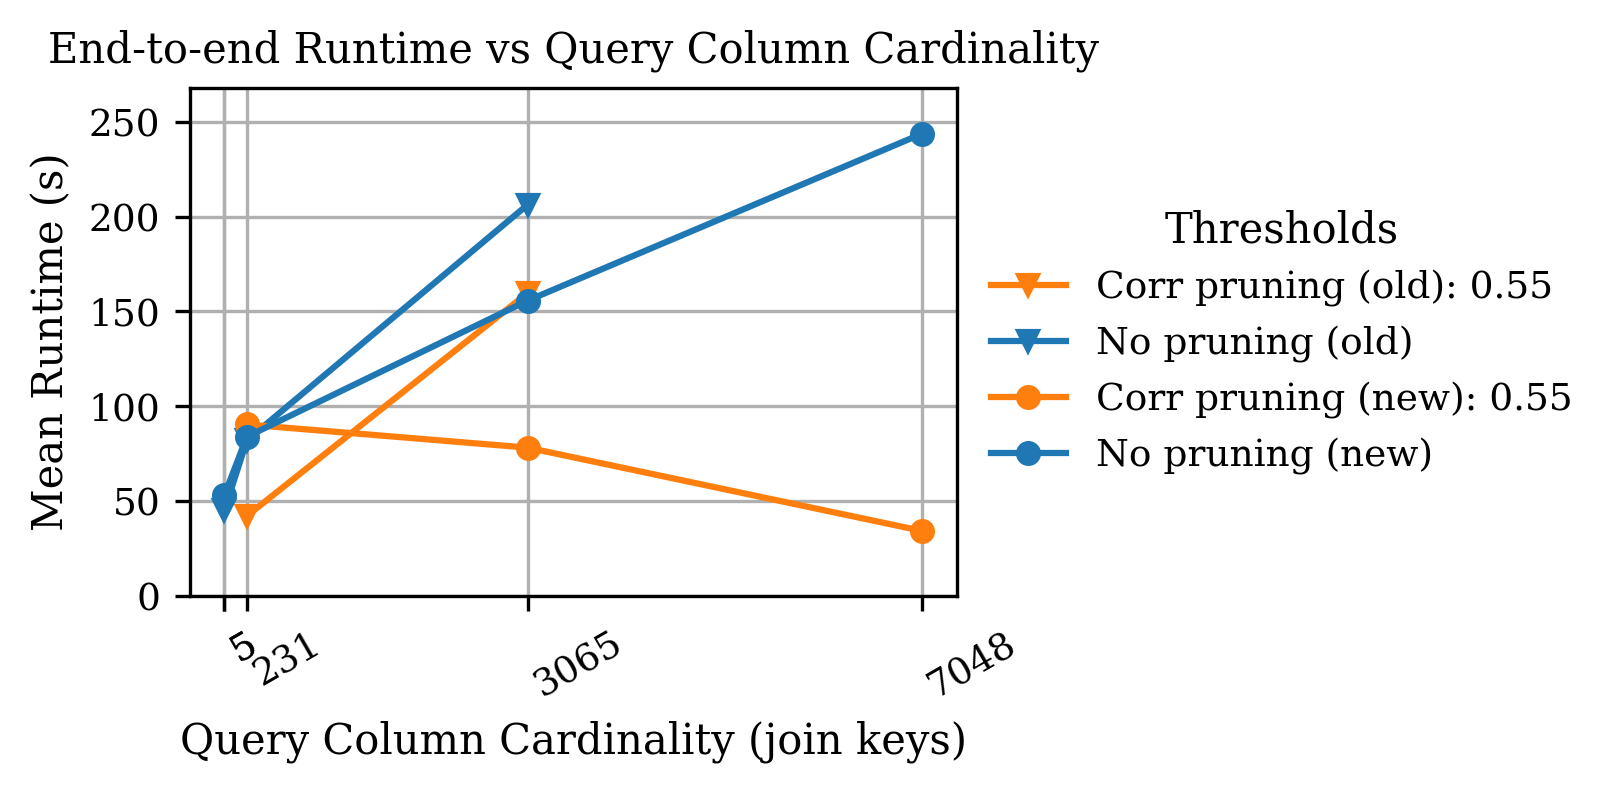

In [54]:
y_end_to_ends = []
markers = ['v', 'o']
fig, ax = plt.subplots()
i = 0
for d in [end_to_end2, end_to_end]:
    for (var_threshold, corr_threshold), group in d.group_by(['var_threshold', 'corr_threshold']):
        group = group.sort(['var_threshold', 'corr_threshold'])
        if var_threshold > 0 and corr_threshold == 0.0:
            np.random.seed(42)
            group = group.with_columns(pl.col('runtime') + 1+ np.random.rand())
        x_end_to_end = group['query_col_cardinality'].to_list()
        y_end_to_end = group['runtime'].to_list()
        y_end_to_ends.extend(y_end_to_end)
        colors = {
            (0.0, 0.0): 'tab:blue',
            (0.0, 0.55): 'tab:orange',
        }
        color = colors.get((var_threshold, corr_threshold), 'tab:gray')
        if var_threshold == 0.0 and corr_threshold == 0.0:
            if markers[i] == 'o':
                label = 'No pruning (new)'
            else:
                label = 'No pruning (old)'
        else:
            if markers[i] == 'o':
                label = f'Corr pruning (new): {corr_threshold}'
            else:
                label = f'Corr pruning (old): {corr_threshold}'
        ax.plot(x_end_to_end, y_end_to_end, marker=markers[i],
                label=label,
                color=color)
    i += 1

plt.xlabel('Query Column Cardinality (join keys)')
plt.ylabel('Mean Runtime (s)')
plt.ylim(0, max(y_end_to_ends) * 1.1)
plt.title('End-to-end Runtime vs Query Column Cardinality')
plt.legend(title='Thresholds', loc='center left', bbox_to_anchor=(1, 0.5))
plt.xticks([5]+x_end_to_end, rotation=30, ha='left')
# plt.yscale('log')
plt.grid(True)
plt.show()

In [40]:
end_to_end.write_csv('end_to_end.csv')